## **Spectroscopic IROS Reconstruction**

In [1]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
from astropy.io.fits import FITS_rec
from tqdm import tqdm

from bloodmoon.types import CoordEquatorial
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
import darksun as ds
from darksun.data import Log
from darksun.benchmarking import source_catalogue_data
from darksun.data import DataLoader, CatalogueLoader

from IROSrec.iros.optim import iros_singleCAM
from IROSrec.iros.procedure import run_IROS, get_sources_database


ds.show.set_figures_darkbkg()

In [2]:
BASE_PATH: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data"
SIM_PATH: str = f"{BASE_PATH}/Simulations"
OUT_PATH: str = f"{BASE_PATH}/Outputs"

# BASE_PATH: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
# SIM_PATH = OUT_PATH = BASE_PATH



# MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
MASK_FITS: str = "mask_NTHT_20250725.fits"
UPS_X: int = 2
UPS_Y: int = 1

wfm: CodedMaskCamera = codedmask(f"{SIM_PATH}/{MASK_FITS}", UPS_X, UPS_Y)



# SKYFIELD: str = "IROSDummy"
# DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"
SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"

ID_CAMERA_A: str = "cam1a"
DATASET: str = "reconstructed"
PSFY = True if DATASET == 'reconstructed' else False

filepaths: dict[str, dict[str, Path]] = simulation_files(f"{SIM_PATH}/{SKYFIELD}/{DATA_FITS}")

In [3]:
# - data gathering from specific direction
#   NOTE: Filtering the whole photons list by specific incoming direction associated with a source
#         is just a way to reduce the computational cost of data handling operations.
#         Since we are dealing with a WM sim, we know the actual photons directions. In a real
#         obs this info is lost in the encoding phase (hence, we can only filter for energy).
#   NOTE: If the spectroscopic analysis is performed AFTER a first IROS reconstruction, the sources
#         coords in the camera local-frame are known, and can be utilised in the sky image to select
#         subsections of the skymap for the spectroscopic analysis (e.g., as an external trigger).

def get_source_coords(sourceID: str, catalogue: CatalogueLoader) -> CoordEquatorial:
    """Extracts the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def select_target_srcs(
    photons: FITS_rec,
    srcIDs: str | tuple[str, ...],
    catalogue: CatalogueLoader,
) -> FITS_rec:
    """Filters the input photon list for the given sources equatorial coords."""
    srcIDs_ = (srcIDs,) if isinstance(srcIDs, str) else srcIDs
    coords = tuple(get_source_coords(src, catalogue) for src in srcIDs_)
    phs = ds.select_source_photons(coords, photons, False)
    return phs

In [4]:
# - energy bands scheduler and filtering

type EnergyRange = tuple[float, float]
type EnergySchedule = dict[int, EnergyRange]

def eband_schedule(emin: float, emax: float, ebins: float) -> EnergySchedule:
    """Defines a linear schedule for the energy bands to analyse."""
    if not (emax > emin) or (emax - emin < ebins):
        raise ValueError('Invalid energy band boundary values.')
     
    nruns = int((emax - emin) / ebins)
    schedule = {run: (float(emin), float(emin + run * ebins)) for run in range(1, nruns + 1)}
    return schedule

def eband_custom_schedule(e_start: float, ebins: float | tuple[float, ...]) -> EnergySchedule:
    """Defines a custom energy bands schedule with given `ebins` size, from `e_start`."""
    ebins_ = (ebins,) if isinstance(ebins, (int, float)) else ebins
    schedule = {
        (run + 1): (float(e_start), float(e_start + cumbin))
        for run, cumbin in enumerate(np.cumsum(ebins_))
    }
    return schedule

def select_eband_phs(photons: FITS_rec, eband: EnergyRange) -> FITS_rec:
    """Filters the input photon list in the given energy band."""
    E_min, E_max = eband
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)

In [5]:
from bloodmoon.mask import count, variance
from darksun.handle import save_pickle, load_pickle

# - define operations for single energy band IROS run

def perform_IROS(
    camera: CodedMaskCamera,
    detector: NDArray,
    max_iterations: int,
    camID: str | None = None,
    **iros_kwargs: Any,
) -> Log:
    """Runs the IROS procedure and stores optimised sources params."""
    loop = iros_singleCAM(camera, detector, max_iterations, **iros_kwargs)
    log, _ = run_IROS(camera, loop, camID)
    return log


def run_IROS_spectr_rec(
    camera: CodedMaskCamera,
    sdl: DataLoader,
    srcIDs: str | tuple[str, ...],
    schedule: EnergySchedule,
    catalogue: CatalogueLoader,
    vignetting: bool = True,
    screening: bool = True,
    save_to: str | None = None,
    **iros_kwargs: Any,
) -> dict[EnergyRange, Log]:
    """
    Performs the spectroscopic IROS reconstruction in the specified energy bands.

    NOTE:
        * The BKG is filtered out (if CXB phs are flagged, they can be kept
          in the data by adding the flag ID to the `srcIDs` sequence).
    """
    srcIDs_ = (srcIDs,) if isinstance(srcIDs, str) else srcIDs
    out: dict[EnergyRange, Log] = {}

    # filter for sources
    photons = select_target_srcs(sdl.DLdata, srcIDs_, catalogue)

    # run eband reconstr
    _det, _ = count(camera, sdl.DLdata)
    varmap = variance(camera, _det)
    max_iterations = 2 * len(srcIDs_)
    rec_loop = tqdm(list(schedule.items()))

    for runID, eband in rec_loop:
        rec_loop.set_description(f'Run {runID} | IROS reconstr - {eband} keV')
        phs = select_eband_phs(photons, eband)
        eband_detector, _ = count(camera, phs)
        log = perform_IROS(camera, eband_detector, max_iterations, varmap=varmap, **iros_kwargs)
        log = get_sources_database(camera, sdl, catalogue, log, vignetting, screening)
        out[eband] = log
    
    if save_to is not None: save_pickle(out, save_to)
    
    return out

In [6]:
from scipy.signal import convolve
from scipy.ndimage import gaussian_filter

from bloodmoon.coords import pos2shift
from bloodmoon.optim import _wfm_psfy, model_sky

from IROSrec.iros.optim import solver
from IROSrec.iros.types import OptResult


def custom_model_for_psfy(sigma: float) -> Callable[[CodedMaskCamera, NDArray], NDArray]:
    """
    Func factory for detector resolution effect modelling.
    """
    def _wfm_psfy_kernel(camera: CodedMaskCamera) -> NDArray:
        """
        Returns detector spatial resolution norm conv kernel.
        """
        PSFY_GAUSS_PARAMS = {
            "sigma": sigma,
            "mode": 'constant',
            "cval": 0.0,
        }
        # we take a whole slit to have a good kernel spatial extension
        px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
        slit_dim = camera.specs.slit_deltay
        # the kernel must have the same binning as the mask elements
        bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
        kernel = _wfm_psfy(bins).reshape(len(bins), -1)
        # from tests, the modsech should be modulated with a Gaussian
        psfy = gaussian_filter(kernel, **PSFY_GAUSS_PARAMS)
        return psfy / np.sum(psfy)

    def model(camera: CodedMaskCamera, shadowgram: NDArray) -> NDArray:
        """Custom model for detector resolution effect."""
        psfy_kernel = _wfm_psfy_kernel(camera)
        return convolve(shadowgram, psfy_kernel, mode='same')
    
    return model


def custom_optimiser(
    camera: CodedMaskCamera,
    vignetting: bool | Callable[[CodedMaskCamera, NDArray, float, float], NDArray],
    psfy: bool | Callable[[CodedMaskCamera, NDArray], NDArray],
    fit_weights: NDArray | Callable[[NDArray], NDArray] | None = None,
    camera_coding_power: float = 0.85,
    verbose: bool = False,
) -> Callable[[NDArray, tuple[int, int]], OptResult]:
    """
    Configures the IROS optimiser for source parameters fitting.
    """
    def process_skyimg(
        sky: NDArray,
        pos: tuple[int, int],
    ) -> NDArray:
        """
        Processes the sky image for optimisation.
        """
        # here we crop the source PSF slit plus an offset to account for
        # shifts and to accomodate the `curve_fit` optimisation:
        #   - along y (coarse dir) we insert an offset of `5 * upscaling`, which
        #     is ~ 1/6 of the upsampled PSF slit dimension;
        #   - along x (fine dir) we insert an offset of `2 + upscaling`, to
        #     avoid the bkg contributes from the surrounding pixels;
        # NOTE: if the offset is smaller than at least the shifts bounds in
        # `optimize()`, the optimisation procedure may fail for some sources
        psf_slit_px_y, psf_slit_px_x = (
            int(camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay),
            int(camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax),
        )
        offset_y, offset_x = (
            5 * camera.upscale_f.y, 2 + camera.upscale_f.x,
        )
        crop_y, crop_x = (
            psf_slit_px_y + offset_y, psf_slit_px_x + offset_x,
        )
        i, j = pos
        slice_y, slice_x = (
            slice(i - crop_y, i + crop_y + 1), slice(j - crop_x, j + crop_x + 1),
        )
        cropped = sky[slice_y, slice_x]
        return cropped.flatten()

    def _ModelShiftFluence(arg_sky: tuple[int, int]) -> Callable[[NDArray, float, float, float], NDArray]:
        """
        Initialises the source model.
        """
        def f(x: NDArray, shift_x: float, shift_y: float, fluence: float) -> NDArray:
            """Models the source sky image."""
            modeled = model_sky(camera, shift_x, shift_y, fluence, vignetting, psfy)
            return process_skyimg(modeled, arg_sky)
        
        return f
    
    def _ModelSigmaFluence(
        arg_sky: tuple[int, int],
        shift_x: float,
        shift_y: float,
    ) -> Callable[[NDArray, float, float], NDArray]:
        """
        Initialises the source model for psfy sigma and fluence fit.
        """
        def f(x: NDArray, sigma: float, fluence: float) -> NDArray:
            psfy_model = custom_model_for_psfy(sigma)
            modeled = model_sky(camera, shift_x, shift_y, fluence, vignetting, psfy_model)
            return process_skyimg(modeled, arg_sky)
        
        return f

    def optimiser(
        sky: NDArray,
        arg_sky: tuple[int, int],
    ) -> OptResult:
        """
        Performs the optimization to fit a point source model to sky image data.
        """
        # -------------   NOTE: first optim - SRC POS and FLUENCE   -------------
        print('### - FIRST FIT ROUTINE - ###')
        model_func = _ModelShiftFluence(arg_sky)
        sky_peak = sky[*arg_sky]

        # setup solver params
        # * setup source data + std
        sky_ydata = process_skyimg(sky, arg_sky)
        if fit_weights is not None:
            weights = (
                fit_weights if isinstance(fit_weights, np.ndarray)
                else fit_weights(sky_ydata)
            )
        else:
            weights = np.ones_like(sky_ydata)
        # * extract source coords and counts starting values
        sx_start, sy_start = pos2shift(camera, *arg_sky)
        cts_start = (
            sky_peak / camera_coding_power if psfy is not False else sky_peak
        )
        start_params_vals = np.array([sx_start, sy_start, cts_start])
        # * setup fit params boundaries
        #    - the shifts are allowed to fluctuate in a small pixel box since
        #      the extracted position is close enough to the true source pos
        #      A small box also account for superimposed or close sources,
        #      which may introduce biases in the source fit procedure
        #    - the box is built from the digital upsampling since in the worst
        #      case (source at 45 deg wrt optical axis) the high energy detected
        #      photons median absorption distance is 225um. The projection of this
        #      distance on the camera plane is always smaller than `px_size / ups`  
        #    - the fluence cannot be smaller than the one observed at the peak,
        #      and we insert a lower value just for precaution (if simulating
        #      for example an infinite detector spatial resolution)
        px_dim_x, px_dim_y = (
            camera.specs.mask_deltax / camera.upscale_f.x,
            camera.specs.mask_deltay / camera.upscale_f.y,
        )
        bounds = [
            (
                max(sx_start - camera.upscale_f.x * px_dim_x, camera.bins_sky.x[0]),
                max(sy_start - camera.upscale_f.y * px_dim_y, camera.bins_sky.y[0]),
                0.95 * sky_peak,
            ),
            (
                min(sx_start + camera.upscale_f.x * px_dim_x, camera.bins_sky.x[-1]),
                min(sy_start + camera.upscale_f.y * px_dim_y, camera.bins_sky.y[-1]),
                1.5 * sky_peak,
            ),
        ]

        # perform optimisation
        slvr_kwargs = {
            # - solver kwargs
            'p0': start_params_vals,
            'sigma': weights,
            'bounds': bounds,
            'method': 'trf',
            # - least square kwargs
            'jac': '3-point',
            'ftol': 1e-8,
            'xtol': 1e-8,
            'x_scale': 'jac',
            'loss': 'linear',
        }
        result = solver(
            func=model_func,
            xdata=np.arange(len(sky_ydata)),
            ydata=sky_ydata,
            verbose=verbose,
            **slvr_kwargs,
        )

        
        # -------------   NOTE: second optim - PSFY KERNEL and SRC FLUENCE   -------------
        print('### - SECOND FIT ROUTINE - ###')
        sx, sy = map(float, result.params[:-1])
        model_func = _ModelSigmaFluence(arg_sky, sx, sy)

        # setup solver params
        # * setup start vals
        _sigma_start = 0.18
        start_params_vals = np.array([_sigma_start, cts_start])
        # * setup fit params boundaries
        bounds = [
            (0.0, 0.95 * sky_peak),
            (1.0, 1.5 * sky_peak),
        ]

        # perform optimisation
        # * update fit start vals
        slvr_kwargs['p0'] = start_params_vals
        slvr_kwargs['bounds'] = bounds

        result = solver(
            func=model_func,
            xdata=np.arange(len(sky_ydata)),
            ydata=sky_ydata,
            verbose=verbose,
            **slvr_kwargs,
        )
        s, cts = map(float, result.params)

        # gather out vals: coords + cts
        out = OptResult(np.array([sx, sy, cts]), np.empty(1))

        return out
    
    return optimiser

In [7]:
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# schedule: EnergySchedule = eband_schedule(2.0, 10.0, 2.0)

ebins = [0.5] * 26
schedule: EnergySchedule = eband_custom_schedule(2.0, ebins)

print(schedule)

{1: (2.0, 2.5), 2: (2.0, 3.0), 3: (2.0, 3.5), 4: (2.0, 4.0), 5: (2.0, 4.5), 6: (2.0, 5.0), 7: (2.0, 5.5), 8: (2.0, 6.0), 9: (2.0, 6.5), 10: (2.0, 7.0), 11: (2.0, 7.5), 12: (2.0, 8.0), 13: (2.0, 8.5), 14: (2.0, 9.0), 15: (2.0, 9.5), 16: (2.0, 10.0), 17: (2.0, 10.5), 18: (2.0, 11.0), 19: (2.0, 11.5), 20: (2.0, 12.0), 21: (2.0, 12.5), 22: (2.0, 13.0), 23: (2.0, 13.5), 24: (2.0, 14.0), 25: (2.0, 14.5), 26: (2.0, 15.0)}


In [8]:
OUT_RESULTS_PATH: str = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/IROS_paper'
# OUT_RESULTS_PATH = "/mnt/d/PhD_AASS/Coding/Images_fits"

DATA_ID: str = 'out_IROS_data_test_2-15keV_1ks_SCOX1__dblFIT_wPSFYsigma.pickle'

srcIDs = (
    'scox1', #'gx5-1', 'gx349+2', 'gx17+2',
)

fp: Path = Path(f'{OUT_RESULTS_PATH}/{DATA_ID}')
if not fp.exists():
    def comp_fit_weights(obs: NDArray) -> NDArray:
        """Computes the weights for the loss metric in the optimisation procedure."""
        return 1.0 / np.sqrt(np.clip(obs, a_min=1.0, a_max=None))
    
    optimiser = custom_optimiser(
        camera=wfm,
        vignetting=True,
        psfy=PSFY,
        fit_weights=comp_fit_weights,
        verbose=True,
    )

    out_logs = run_IROS_spectr_rec(
        camera=wfm,
        sdl=sdlA,
        srcIDs=srcIDs,
        schedule=schedule,
        catalogue=catA,
        save_to=fp,
        optimiser=optimiser,
    )
else:
    out_logs = load_pickle(fp)

## USING BULK MASK with 1.5 mm cover ##


Run 1 | IROS reconstr - (2.0, 2.5) keV:   0%|          | 0/26 [00:00<?, ?it/s]

# Looping around the FOV...


### - FIRST FIT ROUTINE - ###

## Optimisation Results:
  * p[0]:
      - START.: 43.8750000
      - OPTIM.: 43.9095630 +/- 0.0002044
      - GAIN.: 0.079 %
  * p[1]:
      - START.: 78.0000000
      - OPTIM.: 78.1851655 +/- 0.0101912
      - GAIN.: 0.237 %
  * p[2]:
      - START.: 40045.6300454
      - OPTIM.: 38743.0383889 +/- 44.4618404
      - GAIN.: -3.253 %

## Fit Report:
  - func calls (also # of iters): 6
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values

### - SECOND FIT ROUTINE - ###



## Optimisation Results:
  * p[0]:
      - START.: 0.1800000
      - OPTIM.: 1.0000000 +/- 0.1880149
      - GAIN.: 455.556 %
  * p[1]:
      - START.: 40045.6300454
      - OPTIM.: 38830.1518682 +/- 48.1024544
      - GAIN.: -3.035 %

## Fit Report:
  - func calls (also # of iters): 6
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



...

### - FIRST FIT ROUTINE - ###

## Optimisation Results:
  * p[0]:
      - START.: 43.8750000
      - OPTIM.: 43.9148441 +/- 0.0000157
      - GAIN.: 0.091 %
  * p[1]:
      - START.: 78.0000000
      - OPTIM.: 78.0564410 +/- 0.0008375
      - GAIN.: 0.072 %
  * p[2]:
      - START.: 1040289.4184444
      - OPTIM.: 993736.9422288 +/- 89.1340586
      - GAIN.: -4.475 %

## Fit Report:
  - func calls (also # of iters): 7
  - procedure msg: Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality

### - SECOND FIT ROUTINE - ###


IROS sky-reconstruction: 1it [00:10, 10.98s/it]


## Optimisation Results:
  * p[0]:
      - START.: 0.1800000
      - OPTIM.: 0.6830188 +/- 0.0190253
      - GAIN.: 279.455 %
  * p[1]:
      - START.: 1040289.4184444
      - OPTIM.: 994770.7317322 +/- 91.2085898
      - GAIN.: -4.376 %

## Fit Report:
  - func calls (also # of iters): 9
  - procedure msg: Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality


No candidates left...



Run 26 | IROS reconstr - (2.0, 15.0) keV: 100%|██████████| 26/26 [05:22<00:00, 12.41s/it]


# Comparing with Catalogue...
# Successful comparison!
# Saving data...
# Saving completed!


In [9]:
for runID, (eband, log) in enumerate(out_logs.items()):
    print(f'Run {runID + 1}, eband {eband} keV  |  Sources: {log.log['ID']} (brightest: {log.log['ID_brightest']})')

Run 1, eband (2.0, 2.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 2, eband (2.0, 3.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 3, eband (2.0, 3.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 4, eband (2.0, 4.0) keV  |  Sources: ['scox1', 'lemx-S1'] (brightest: ['scox1', 'lemx-S1'])
Run 5, eband (2.0, 4.5) keV  |  Sources: ['scox1', 'lemx-S1'] (brightest: ['scox1', 'lemx-S1'])
Run 6, eband (2.0, 5.0) keV  |  Sources: ['scox1', 'lemx-S1'] (brightest: ['scox1', 'lemx-S1'])
Run 7, eband (2.0, 5.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 8, eband (2.0, 6.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 9, eband (2.0, 6.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 10, eband (2.0, 7.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 11, eband (2.0, 7.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 12, eband (2.0, 8.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 13, eband (2.0, 8.5) keV  |  Sources: [

In [10]:
def _same_srcs_metric__keepMinLen(runs_logs: list[Log]) -> int:
    """Temporary metric to discern max N of total sources to account for."""
    return min([len(log.log['ID']) for log in runs_logs])

def _get_ebins(ebands: list[EnergyRange]) -> NDArray:
    """Computes the energy bins from the runs integral energy bands."""
    ebands_ = np.array(ebands)
    esteps = np.diff(ebands_, axis=0)[:, -1]
    esteps = np.concat((np.diff(ebands_[0]), esteps))
    ebins = np.concat(([ebands_[0][0]], ebands_[0][0] + np.cumsum(esteps)))
    return ebins

def _get_differential(observable: str, runs_logs: list[Log], up_to: int | None = None) -> NDArray:
    """Computes the ebands integrated subtraction for specified observable."""
    # gather values across runs and sources
    vals = np.array([log.log[f'{observable}'][:up_to] for log in runs_logs])
    # compute eband-subtraction + reintroduce first element
    vals_cumsubtr = np.concat(([vals[0]], np.diff(vals, axis=0)))
    return vals_cumsubtr


def compute_counts(runs: dict[EnergyRange, Log]) -> tuple[NDArray, NDArray]:
    """
    Computes the sources counts from IROS reconstruction by subtraction in cumulative ebands.
    Returns the energy bins and the sources counts per eband (per column, across runs).
    * TODO: insert check on logged data to match srcs to cts vals across runs.
    """
    # NOTE: gather vals, we assume that cts are coherent with respective srcs across runs
    ebins = _get_ebins(list(runs.keys()))
    _last_to_keep = _same_srcs_metric__keepMinLen(list(runs.values()))
    cts_cumsubtr = _get_differential('fluence', list(runs.values()), up_to=_last_to_keep)
    return ebins, cts_cumsubtr

def compute_spectra(runs: dict[EnergyRange, Log]) -> tuple[NDArray, NDArray]:
    """
    Computes the sources spectra from IROS reconstruction by rate subtraction in cumulative ebands.
    Returns the energy bins and the sources spectra (per column, across runs).
    NOTE: We use the rates to neglect the effective area in different ebands.
    * TODO: insert check on logged data to match srcs to rates vals across runs.
    """
    # NOTE: gather vals, we assume that flxs are coherent with respective srcs across runs
    ebins = _get_ebins(list(runs.keys()))
    esteps = np.diff(ebins)
    _last_to_keep = _same_srcs_metric__keepMinLen(list(runs.values()))
    rate_cumsubtr = _get_differential('rate', list(runs.values()), up_to=_last_to_keep)
    return ebins, rate_cumsubtr / esteps[:, None]

In [11]:
def get_src_cts(
    camera: CodedMaskCamera,
    sdl: DataLoader,
    srcID: str,
    ebins: NDArray,
    catalogue: CatalogueLoader,
) -> NDArray:
    """Computes the source collected photons in given energy bins."""
    cts: list[float] = []
    esteps = np.diff(ebins)
    photons = select_target_srcs(sdl.DLdata, srcID, catalogue)

    loop = tqdm(enumerate(ebins[:-1]), f'Gathering from {srcID.upper()}')
    for idx, e in loop:
        phs = select_eband_phs(photons, (float(e), float(e + esteps[idx])))
        eband_detector, _ = count(camera, phs)
        cts.append(eband_detector.sum())
    
    return np.array(cts)


def get_src_spectr(sdl: DataLoader, ebins: NDArray, cts: NDArray,) -> NDArray:
    """Computes the source spectrum from counts in given energy bins."""
    esteps = np.diff(ebins)
    exposure = sdl.header['EXPOSURE']
    return cts / exposure / esteps

In [12]:
ebins, spectra = compute_spectra(out_logs)
_, iros_cts = compute_counts(out_logs)

true_cts = get_src_cts(wfm, sdlA, 'scox1', ebins, catA)
true_spectr = get_src_spectr(sdlA, ebins, true_cts)

Gathering from SCOX1: 26it [00:01, 19.09it/s]


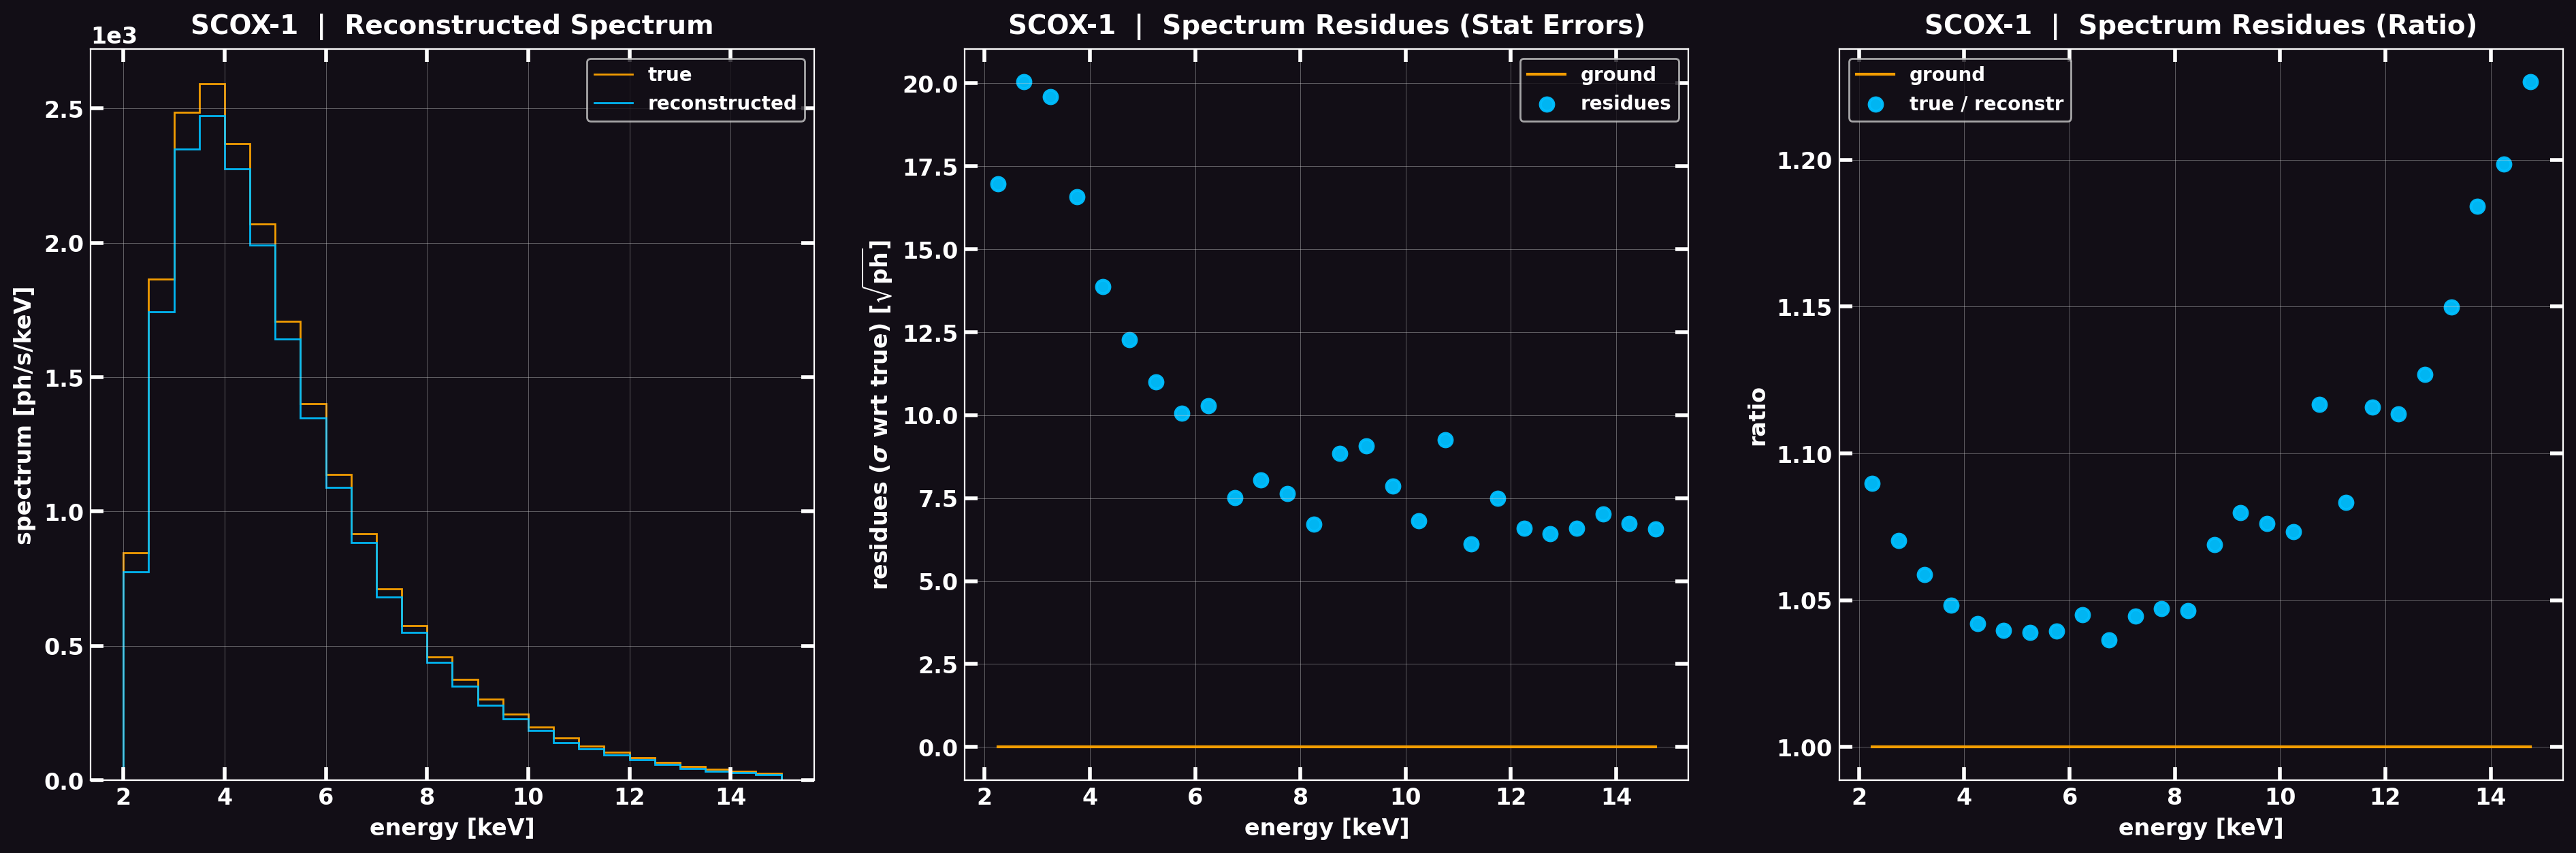

In [14]:
ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=(true_spectr, spectra[:, 0]),
            title='SCOX-1  |  Reconstructed Spectrum',
            x=ebins,
            xlabel='energy [keV]',
            ylabel='spectrum [ph/s/keV]',
            labels=('true', 'reconstructed'),
            style='stairs',
            color=('Orange', 'DeepSkyBlue'),
            # yscale='log',
        ),
        ds.map4plot(
            arrs=(np.zeros_like(true_spectr), (true_cts - iros_cts[:, 0]) / np.sqrt(true_cts)),
            title='SCOX-1  |  Spectrum Residues (Stat Errors)',
            x=ebins[:-1] + np.diff(ebins) / 2,
            xlabel='energy [keV]',
            ylabel='residues ($\\sigma$ wrt true) [$\\sqrt{\\text{ph}}$]',
            labels=('ground', 'residues'),
            style=('plot', 'scatter'),
            color=('Orange', 'DeepSkyBlue'),
        ),
        ds.map4plot(
            arrs=(np.ones_like(true_spectr), true_cts / iros_cts[:, 0]),
            title='SCOX-1  |  Spectrum Residues (Ratio)',
            x=ebins[:-1] + np.diff(ebins) / 2,
            xlabel='energy [keV]',
            ylabel='ratio',
            labels=('ground', 'true / reconstr'),
            style=('plot', 'scatter'),
            color=('Orange', 'DeepSkyBlue'),
        ),
    ),
    ncols=3,
    save_to=f'{OUT_RESULTS_PATH}/{DATA_ID}_spectrs.png',
)